# ORF307 Homework 8

## Q1: A Small Integer Programming Problem

In [201]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

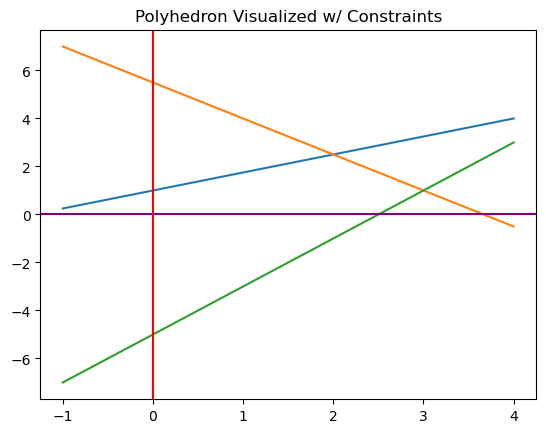

[array([2. , 2.5]), array([4.8, 4.6]), array([-0.,  1.]), array([-1.33333333,  0.        ]), array([3., 1.]), array([0. , 5.5]), array([3.66666667, 0.        ]), array([ 0., -5.]), array([2.5, 0. ]), array([0., 0.])]
Optimal Value:  -6.9999999986121555
Optimal Point:  [2.  2.5]


In [202]:
# Question 1a Coding Portion

c = np.array([1,2])
A = np.array([[-3, 4], [3, 2], [2, -1]])
b = np.array([4, 11, 5])

x = cp.Variable(2, nonneg=True)
constraints = []
constraints += [A @ x <= b]
objective = cp.Minimize(-c.T @ x)

problem_real = cp.Problem(objective, constraints)

x_range = np.linspace(-1,4,100)
plt.figure()

for a, bi in zip(A,b):
  a1, a2 = a
  y = (bi - a1*x_range)/a2
  plt.plot(x_range, y)
plt.axvline(color="red")
plt.axhline(color="purple")

plt.title("Polyhedron Visualized w/ Constraints")
plt.show()

points = []

D = np.vstack([A, np.array([1,0]), np.array([0,1])])
d = np.hstack([b,np.array([0]),np.array([0])])
for i in range(len(d)):
  for j in range(i+1, len(d)):
    M = np.vstack([D[i], D[j]])
    s = np.linalg.solve(M, np.array([d[i],d[j]]))
    points.append(s)

print(points)
problem_real.solve()
print("Optimal Value: ", problem_real.value)
print("Optimal Point: ", x.value)

### Question 1a Written Response

*(Some work is given in the written portion above)*

The optimal point $x = (2, 2.5)$ for the linear programming relaxation gives the optimal value $\rho_{\mathbb{R}} = -7$. However, since $x_2 = 2.5 \notin \mathbb{Z}$ then the point $x = (2, 2.5)$ is not a feasible solution of the integer programming problem. However, consider the convex hull from Question 1b and recall that the equivalence and optimality theorem  states that the optimal solution exists at an extreme point, and the fact that extreme points exist mean that an optimal solution exists. 

Now, manually calculate the optimal values of each of the extreme points of the convex hull (the computation can be located in the written portion above). The optimal integer point $x = (2, 2)$ with the optimal integer (lowest) cost $\rho_{\mathbb{Z}} = -6$.



## Q2: Planning to Move

In [203]:
# Question 2b Coding Portion

n = 30 # Number of items
m = 10 # Number of boxes
Q = 100 # Truck capacity
# Item sizes
a = np.array([4, 3, 1, 2, 2,
5, 4, 2, 4, 2,
4, 1, 5, 2, 1,
3, 5, 3, 3, 3,
4, 5, 5, 2, 3,
3, 3, 2, 2, 2])
# Box sizes
b = np.array([7, 19, 10, 14, 10, 12, 13, 10, 15, 14])

B = a.copy()

for i in range(len(b)-1):
  A = np.vstack([B, a])
  B = A.copy()

y = cp.Variable((m,n), boolean=True)
z = cp.Variable(m, boolean=True)

constraints = [
  b.T @ z <= Q,
  a @ y.T <= b,
  cp.sum(y, axis=0) == 1,
  y <= z[:, None]
]

objective_feasible = cp.Minimize(0)
problem_feasible = cp.Problem(objective_feasible, constraints)
problem_feasible.solve(solver=cp.SCIPY)
print(problem_feasible.status)

objective = cp.Minimize(cp.sum(z))
problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.SCIPY)
print(problem.value)

optimal
7.0


## Question 2b Written Portion

Using the `cxvpy` library and the solver `cp.SCIPY`, we see that the mixed-integer formulation shown in the written portion above is indeed feasible and an optimal value and point exists. Specifically, the optimal value for the problem is $7$ suggesting that the minimum number of boxes to successfully fit all the items into the truck is $7$ boxes without constraint violations.